# Churn Prediction — Modeling & Evaluation

## Objectives
In this notebook I train and evaluate two classification models on the processed data from `02_feature_engineering.ipynb`: Logistic Regression as the baseline model and Random Forest to capture any non-linear relationships. I use cross-validation to ensure evaluation reliability, and GridSearchCV for hyperparameter tuning. Model performance is evaluated using accuracy, recall, F1-score, and AUC-ROC — with an emphasis on recall since false negatives (missed churners) are more costly to the business than false positives. Finally, I apply segmentation analysis on `Contract` type to verify model reliability across different customer groups — contract is an actionable variable the business can directly influence to reduce churn.

## Output
- Trained Logistic Regression and Random Forest model
- Recommended model with performance metrics
- Justification for model choice and business relevance/application
- Visualization for README

## 3.1 Setup & Imports

Importing most of the same libraries and absolute paths like numpy, pandas, and `X` and `y` train/test paths. Addition of sklearn model libraries for Logistic Regression, Random Forest GridSearch, cross-validation, evaluation metrics, as well as graphing libraries for README visualization. 

In [1]:
import warnings
warnings.filterwarnings('ignore') # suppress sklearn warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, cross_val_score

# evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import RocCurveDisplay


RANDOM_STATE = 42
X_TRAIN_PATH = '../data/processed/X_train.csv'
X_TEST_PATH = '../data/processed/X_test.csv'
Y_TRAIN_PATH = '../data/processed/y_train.csv'
Y_TEST_PATH = '../data/processed/y_test.csv'

## 3.2 Load Processed Data

Loading the four processed datasets saved from `02_feature_engineering.ipynb` using the path constants defined in `3.1`. `.squeeze()` is applied to `y_train` and `y_test` to convert them from single-column DataFrames to 1D Series, which is the format `sklearn` models expect for target variables.

In [3]:
X_train = pd.read_csv(X_TRAIN_PATH)
X_test = pd.read_csv(X_TEST_PATH)
y_train = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_test = pd.read_csv(Y_TEST_PATH).squeeze()

In [4]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((5634, 22), (1409, 22), (5634,), (1409,))

`.shape` confirms the four datasets were loaded correctly — `X_train` (5634, 22), `X_test` (1409, 22), `y_train` (5634,), `y_test` (1409,) — matching the expected shapes from `02_feature_engineering.ipynb` and confirming 1D target Series after `.squeeze()`. 

## 3.3 Baseline Model — Logistic Regression

I implement Logistic Regression as the baseline model using `sklearn`'s `LogisticRegression`. This is an appropriate model because it models the linear relationship between features and the log-odds of the target, is highly interpretable, and serves as a strong baseline before introducing more complex models like Random Forest. The model is fit on `X_train` and `y_train`, then used to generate both class predictions and probability scores for AUC-ROC evaluation. `random_state=RANDOM_STATE` ensure reproducibility and `class_weight='balanced'` handles the class imbalance identified in EDA (73.5%/26.5%). This tells sklearn to automatically adjust weights inversely proportional to class frequency so that the minority class (churners) gets more weight during training.


In [5]:
# create logistic regression
lr = LogisticRegression(random_state= RANDOM_STATE, class_weight='balanced')
# fit
lr.fit(X_train, y_train)
# predict
y_pred_lr = lr.predict(X_test)
y_pred_proba_lr = lr.predict_proba(X_test)[:,1] # [:,1] selects probability of class 1 (Churn=Yes) for AUC-ROC

To evaluate performance, as stated in the previous markdown, I report accuracy, precision, recall, F1-score, and AUC-ROC. As previously stated, recall on class 1 (Churn=Yes) is the most important metric since missing a potential churn customer is more costly to the business than misclassifying a non-churning customer as churn. Additionally I produce a heatmap confusion matrix to visualize the TP, TN, FP, FN. 

In [6]:
# evaluation metrics
print(classification_report(y_test, y_pred_lr))
print('AUC-ROC score:', roc_auc_score(y_test, y_pred_proba_lr))

              precision    recall  f1-score   support

           0       0.92      0.73      0.82      1036
           1       0.53      0.82      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.81      0.76      0.77      1409

AUC-ROC score: 0.8606829732835095


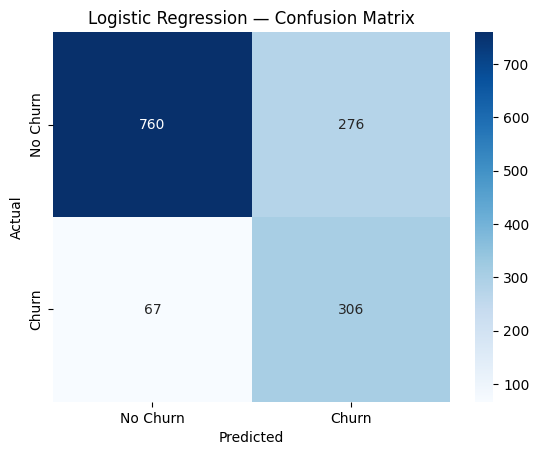

In [7]:
# heatmap confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot = True, fmt = 'd', cmap= 'Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('../images/Logistic_Regression_Confusion_Matrix.png', bbox_inches='tight')
plt.show()

Precision of 0.92 for No Churn (class 0) means that of everything predicted as No Churn 92% were actually non-churners. 0.53 for Churn (class 1) means that only 53% of predicted churners were actually churners. Recall of 0.73 for no Churn means that 73% of actual non-churners were correctly identified, the remaining 27% were incorrectly identified as Churn (FP). Similarly, recall of 0.82 for Churn means 82% of actual churners were correctly identified and the remaining 18% were incorrectly identified as non-churners.

F1 represents the average of precision and recall so the overall ability of the model to predict correctly is 0.82 and 0.64 for No Churn and Churn respectively. accuracy of 0.76 means that the model predicts correctly No Churn and Churn 76% of the time. Lastly the AUC-ROC of 0.86 means the model is good at distinguishing between the two classes. 

The confusion matrix heat map shows (TN: 760, FP: 276, FN: 67, TP: 306). These reflect the relationship between these values and the metrics from the classification report. FP: 276 lowers No Churn recall and Churn precision. FN: 67 lowers Churn recall and No Churn precision. TP: 306 increases Churn precision and recall. TN: 760 increases No Churn precision and recall. 

Overall the baseline Logistic Regression shows decent recall for Churn (0.82) — meaning it catches most actual churners — but poor precision (0.53), indicating it frequently misclassifies non-churners as churners. The AUC-ROC of 0.86 suggests reasonable discriminative ability. However, the F1-score of 0.64 for Churn reflects the precision/recall imbalance — the model trades precision for recall due to `class_weight='balanced'`. Random Forest may improve this balance.